# **IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **IMPORT DATASET**

In [2]:
Train= pd.read_csv('../input/titanic/train.csv')
Test= pd.read_csv('../input/titanic/test.csv')

# **DATA OVERVIEW**

In [3]:
Train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
Train.shape

(891, 12)

# **EDA**

In [6]:
Train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
Train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

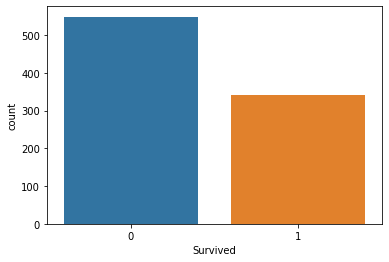

In [8]:
sns.countplot(data=Train, x='Survived')

<AxesSubplot:xlabel='Survived', ylabel='Age'>

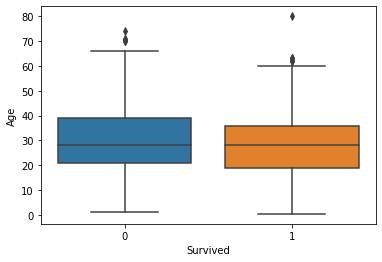

In [9]:
sns.boxplot(data=Train, x='Survived', y='Age')

<AxesSubplot:xlabel='Age', ylabel='Sex'>

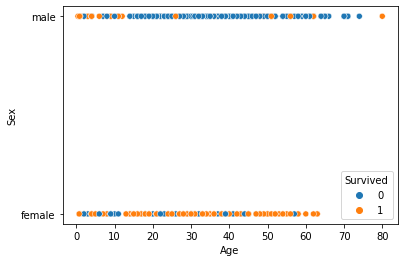

In [10]:
sns.scatterplot(data=Train, x='Age', y='Sex', hue='Survived')

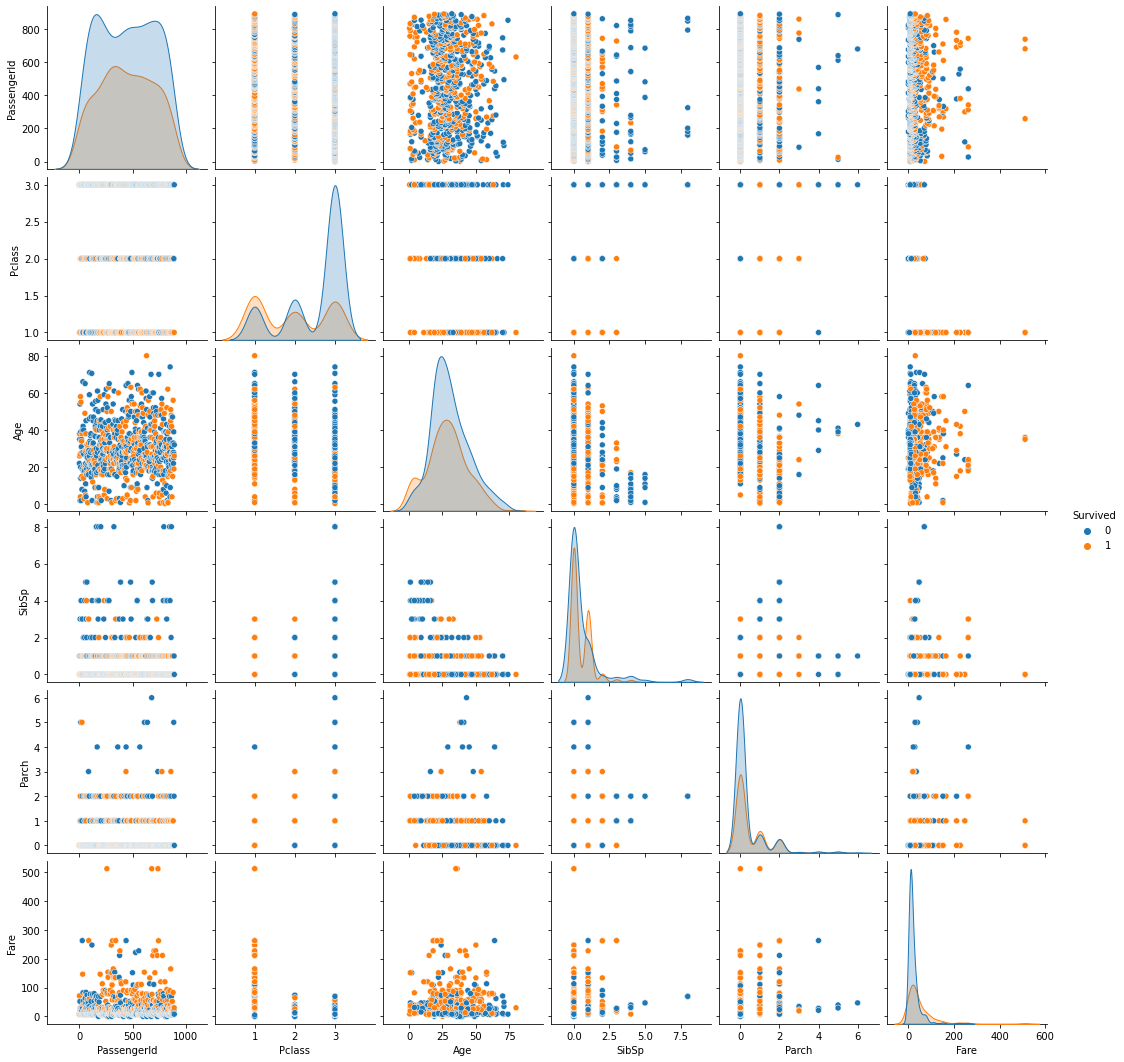

In [11]:
sns.pairplot(Train, hue='Survived')

<AxesSubplot:>

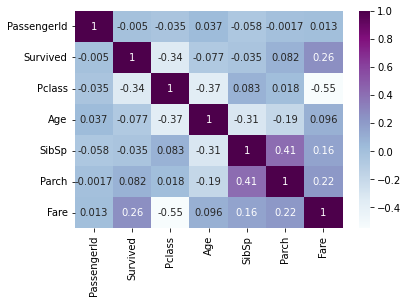

In [12]:
sns.heatmap(Train.corr(), annot=True, cmap="BuPu")

# **DATA PREPARATION**

In [13]:
Train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
Train= Train.drop('Name', axis=1)

In [15]:
(Train.isnull().sum()/len (Train))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [16]:
def missing_percent (Train):
    nan_percent= (Train.isnull().sum()/len (Train))*100
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [17]:
nan_percent= missing_percent(Train)

In [18]:
nan_percent

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

(array([0, 1, 2]),
 [Text(0, 0, 'Embarked'), Text(1, 0, 'Age'), Text(2, 0, 'Cabin')])

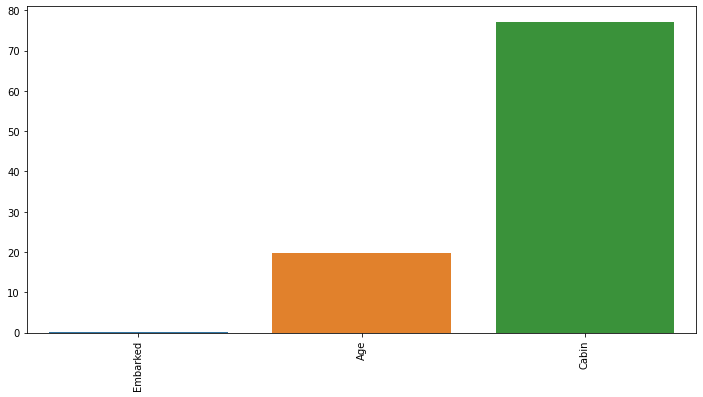

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

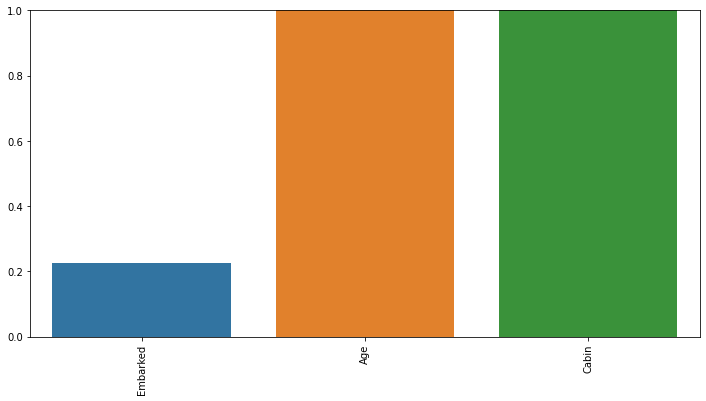

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [21]:
Train[Train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,female,62.0,0,0,113572,80.0,B28,NaN


In [22]:
Train= Train.dropna(subset=['Embarked'], axis=0)

(0.0, 1.0)

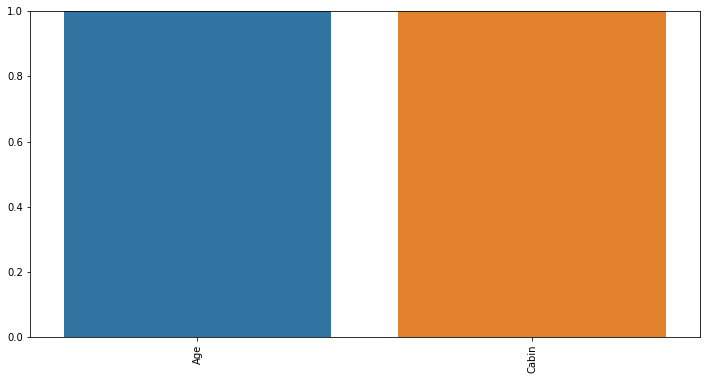

In [23]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [24]:
Train["Age"].fillna(Train["Age"].mean(), inplace = True)

In [25]:
Train.drop("Cabin", axis = 1, inplace = True)

In [26]:
Train['Sex']= Train['Sex'].replace('male', 0)
Train['Sex']= Train['Sex'].replace('female', 1)

In [27]:
Train.drop(['PassengerId', 'Fare', 'Ticket','Embarked'], axis = 1, inplace = True)

In [28]:
Train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

# **FEATURE & LABEL**

In [29]:
X= Train.drop('Survived',axis=1)
y= Train['Survived']

# **TRAIN & TEST**

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# **TRAIN THE MODEL**

In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
model= DecisionTreeClassifier()

In [34]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

# **PREDICTING TEST DATA**

In [35]:
y_pred = model.predict(X_test)

# **EVALUATING THE MODEL**

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

In [37]:
confusion_matrix(y_test, y_pred)

array([[138,  25],
       [ 31,  73]])

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       163
           1       0.74      0.70      0.72       104

    accuracy                           0.79       267
   macro avg       0.78      0.77      0.78       267
weighted avg       0.79      0.79      0.79       267



In [39]:
model.feature_importances_

array([0.13167605, 0.36040021, 0.36143357, 0.09571599, 0.05077418])

In [40]:
pd.DataFrame(index=X.columns, data=model.feature_importances_)

,0
Pclass,0.131676
Sex,0.360400
Age,0.361434
SibSp,0.095716
Parch,0.050774


# **VISUALIZING THE TREE**

In [41]:
from sklearn.tree import plot_tree

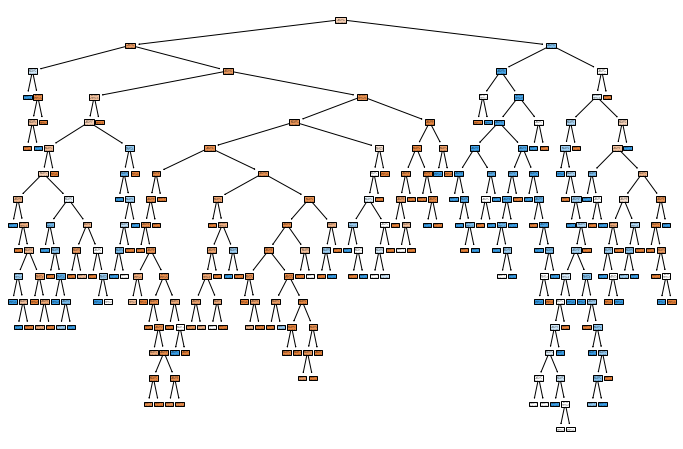

In [42]:
plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names= X.columns);

In [43]:
def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=X.columns);

In [44]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, class_weight=None, presort='deprecated', ccp_alpha=0.0)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "entropy" for the information gain.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strategies are "best" to choose the best split and "random" to choos

In [45]:
pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

              precision    recall  f1-score   support

           0       0.76      0.96      0.85       163
           1       0.90      0.53      0.67       104

    accuracy                           0.79       267
   macro avg       0.83      0.75      0.76       267
weighted avg       0.82      0.79      0.78       267





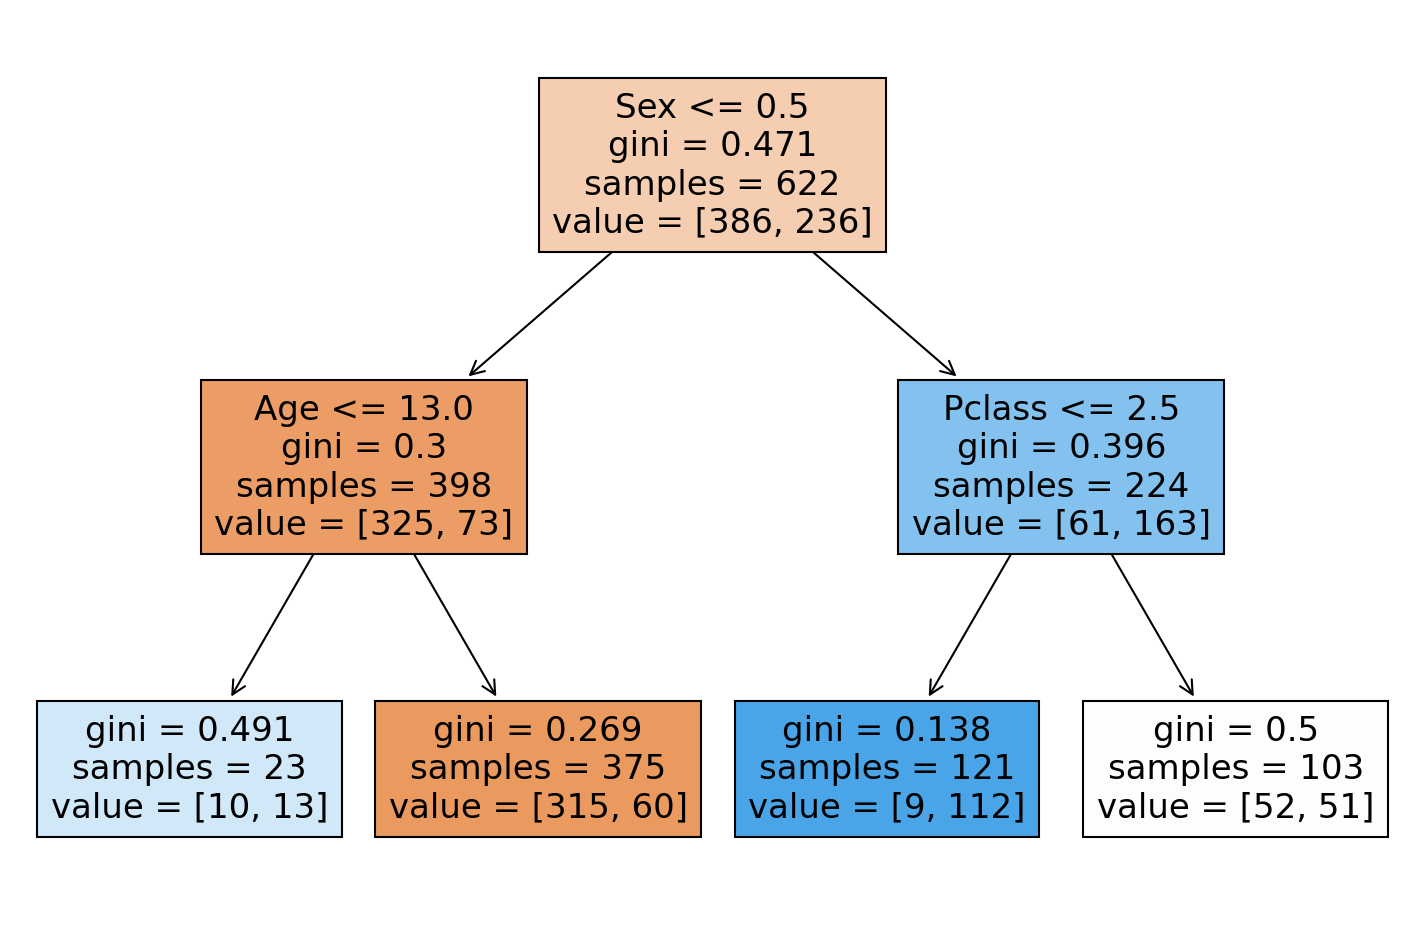

In [46]:
report_model(pruned_tree)

In [47]:
pruned_tree= DecisionTreeClassifier(max_leaf_nodes=3)
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=3)

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       163
           1       1.00      0.45      0.62       104

    accuracy                           0.79       267
   macro avg       0.87      0.73      0.74       267
weighted avg       0.84      0.79      0.76       267





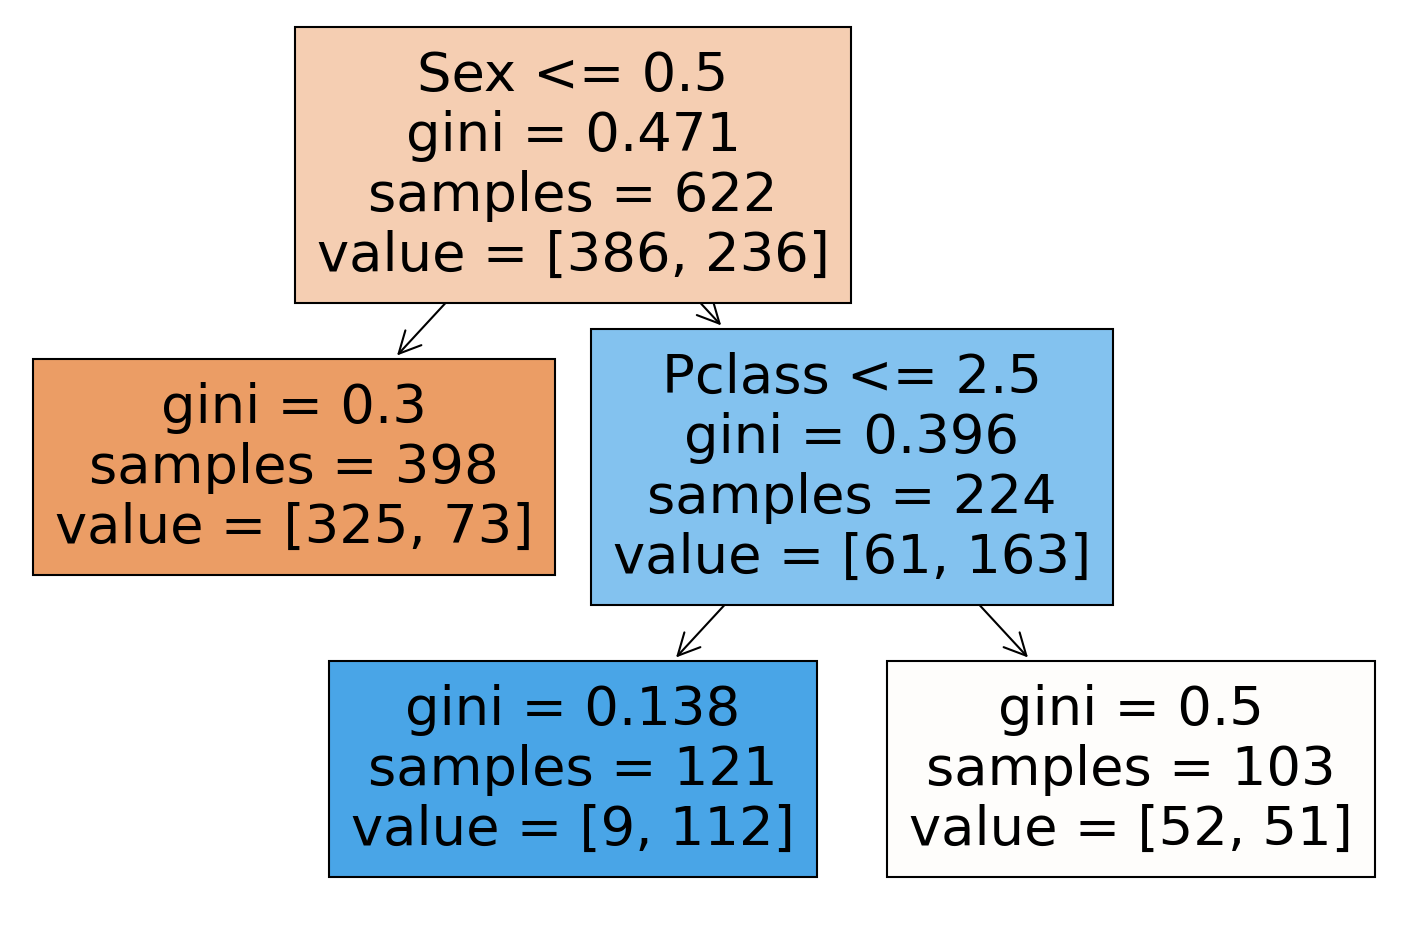

In [48]:
report_model(pruned_tree)

In [49]:
pruned_tree= DecisionTreeClassifier(criterion='entropy')
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       163
           1       0.75      0.69      0.72       104

    accuracy                           0.79       267
   macro avg       0.78      0.77      0.78       267
weighted avg       0.79      0.79      0.79       267





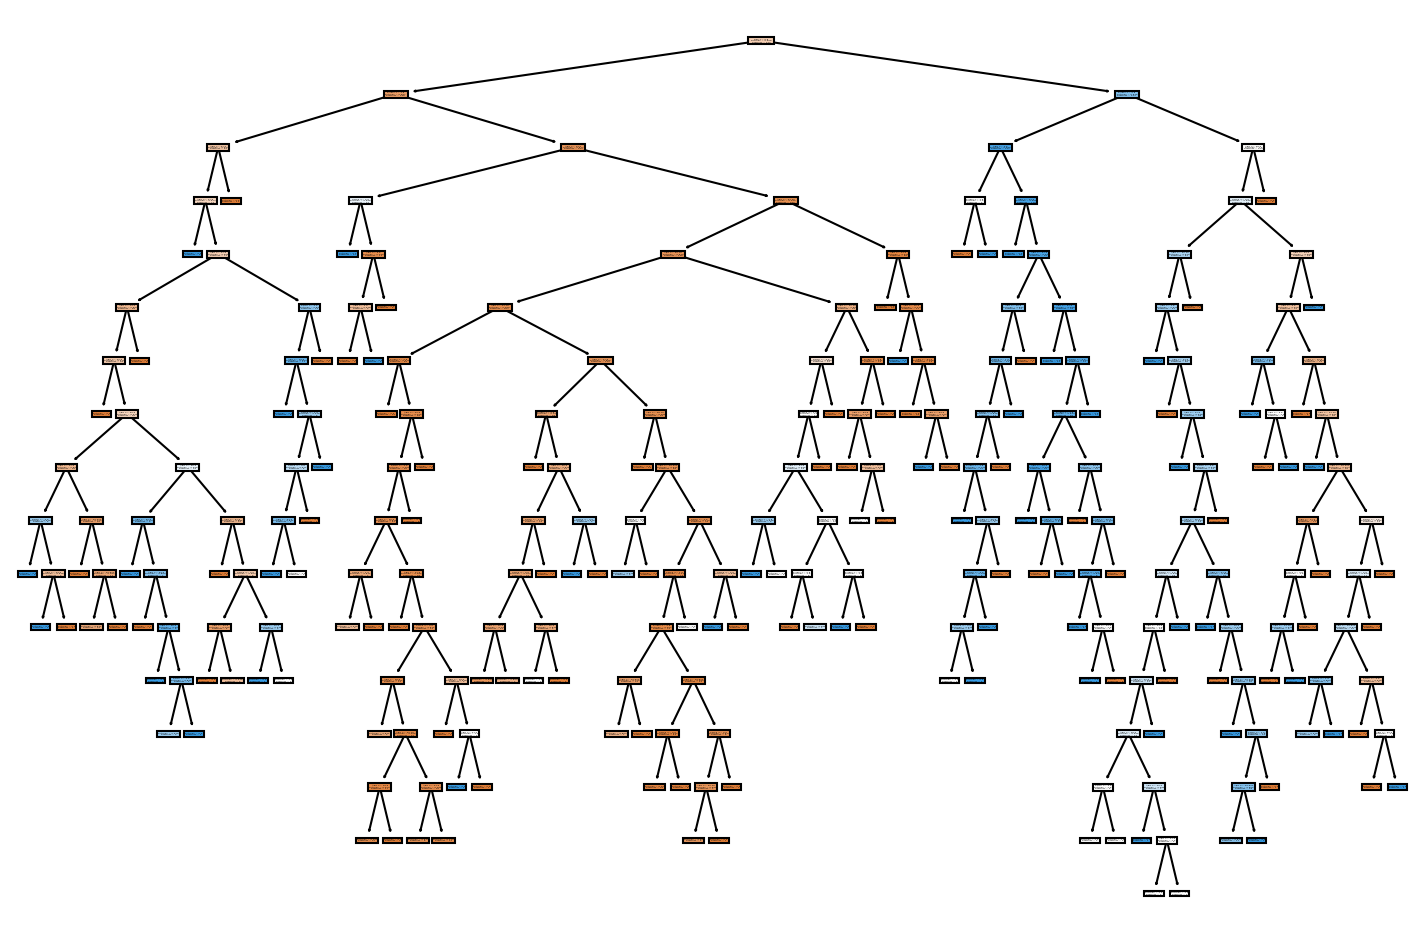

In [50]:
report_model(pruned_tree)